# Detección de Anomalías en Transacciones con Tarjeta de Crédito
**Modelos:** Isolation Forest y Red Neuronal Autoencoder  
**Enfoque:** Aprendizaje no supervisado

## 1. Introducción y Planteamiento del Problema

El fraude con tarjeta de crédito es un problema de alta relevancia en sistemas financieros: ocurre con baja frecuencia pero con consecuencias económicas significativas. El objetivo de este proyecto es construir un sistema capaz de detectar transacciones fraudulentas de forma automática.

### Tipo de aprendizaje

El enfoque adoptado es no supervisado. Los modelos se entrenan exclusivamente con transacciones legítimas y aprenden a representar el comportamiento normal. Una transacción se considera sospechosa cuando se desvía significativamente de ese comportamiento aprendido.

Se aplican dos técnicas complementarias:
- **Aprendizaje basado en aislamiento** (Isolation Forest): identifica anomalías midiendo qué tan fácil es separar un punto del resto del dataset.
- **Aprendizaje basado en reconstrucción** (Autoencoder): identifica anomalías midiendo qué tan mal el modelo puede reconstruir una transacción que no sigue el patrón normal.

Se optó por aprendizaje no supervisado en lugar de clasificación supervisada por dos razones técnicas:

- **Desbalance extremo:** la proporción de transacciones fraudulentas es menor al 1%. Los clasificadores supervisados tienden a optimizar la clase mayoritaria, ignorando los fraudes.
- **Evolución del fraude:** los patrones de fraude cambian con el tiempo. Un modelo que aprende solo el comportamiento normal detecta cualquier desviación, incluyendo patrones de fraude nuevos no vistos en entrenamiento.

Las etiquetas de clase disponibles en el dataset (`is_fraud`) se reservan exclusivamente para evaluar el desempeño de los modelos, no para entrenarlos.

### Variables

- **Entrada:** características de la transacción derivadas del dataset. Las variables exactas que ingresan al modelo se definen en la sección 4, tras el análisis exploratorio y el preprocesamiento.
- **Salida (por modelo):** nivel de anomalía (un rango entre 0 y 1) y una etiqueta binaria (Normal / Anómalo).

## 2. Descripción del Dataset

El dataset utilizado es **Fraud_detection**, publicado en Kaggle por reemkasaab. Fue generado mediante la herramienta Sparkov Data Generation creada por Brandon Harris, que simula transacciones con tarjeta de crédito a partir de perfiles de comportamiento definidos por parámetros como frecuencia de transacciones, distribución de montos por categoría y patrones temporales.

El dataset cubre el período enero 2019 – diciembre 2020 e incluye transacciones simuladas de 1,000 clientes con 800 comerciantes distintos.

**Fuente:** https://www.kaggle.com/datasets/reemkasaab/fraud-detection  
**Licencia:** No especificada

Las dimensiones, distribución de clases, tipos de datos y valores nulos se verifican a continuación directamente sobre el archivo. El archivo cargado presenta 23 columnas: 22 variables del dataset más `Unnamed: 0`, que es el índice numérico del CSV original y no representa información del dominio.

In [1]:
from src.preprocessing import load_data, describe_dataset

df = load_data("data.csv")
describe_dataset(df)

Dimensiones: 1,852,394 filas × 23 columnas

Distribución de clases:
is_fraud
Normal    1842743
Fraude       9651
Name: count, dtype: int64

Porcentaje de fraude: 0.52%

Tipos de datos:
Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

Valores nulos:
Ninguno


### Limitaciones del dataset

- **Naturaleza sintética:** generado por simulación, por lo que puede no cubrir todos los patrones reales de fraude.
- **Licencia no especificada:** limita su uso fuera del ámbito educativo y analítico.
- **Período acotado:** dos años de datos pueden introducir sesgo temporal si los patrones de fraude han cambiado.
- **Sin descripción oficial de columnas:** el dataset no incluye un diccionario de datos formal.

## 3. Análisis Exploratorio (EDA)

Antes de modelar, se exploran los patrones del dataset para entender la naturaleza de los datos y fundamentar las decisiones de preprocesamiento. El EDA busca responder cinco preguntas clave:

1. ¿Qué tan desbalanceado está el dataset?
2. ¿Los montos de transacciones fraudulentas difieren de las normales?
3. ¿Hay categorías de comercio con mayor incidencia de fraude?
4. ¿El fraude sigue patrones temporales (hora del día, día de la semana)?
5. ¿Existe diferencia en la tasa de fraude entre géneros?

In [2]:
from src.eda import plot_class_distribution, plot_amount_by_class, plot_fraud_by_category, plot_time_patterns, plot_fraud_by_gender

Distribución de clases:
  Normal: 1,842,743 (99.48%)
  Fraude: 9,651 (0.52%)


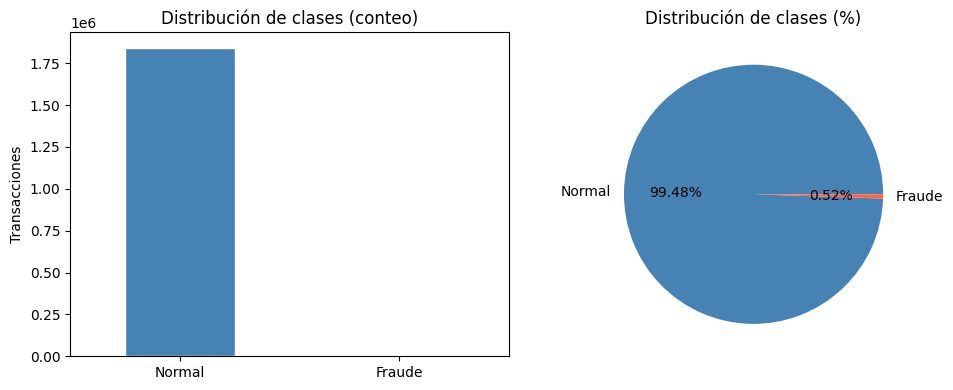

In [3]:
# 1. ¿Qué tan desbalanceado está el dataset?
plot_class_distribution(df)

El dataset presenta un desbalance extremo: el 99.48% de las transacciones son legítimas y apenas el 0.52% son fraudulentas. En el gráfico de barras la clase Fraude es prácticamente invisible, lo que ilustra visualmente por qué un clasificador supervisado entrenado sobre este dataset tendería a predecir siempre "Normal" y así alcanzar un 99.48% de exactitud, una métrica engañosa. Este desbalance es la motivación principal para adoptar un enfoque de detección de anomalías.

Estadísticas de monto por clase:
              count        mean         std   min      25%     50%      75%       max
is_fraud                                                                             
Normal    1842743.0   67.651278  153.548108  1.00    9.610   47.24   82.560  28948.90
Fraude       9651.0  530.661412  391.028873  1.06  240.075  390.00  902.365   1376.04


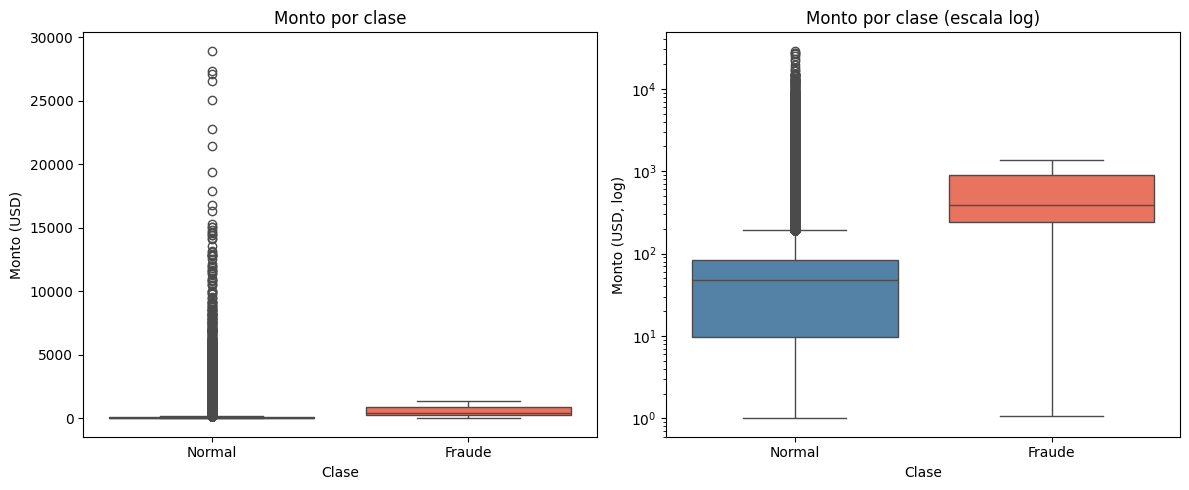

In [4]:
# 2. ¿Los montos de transacciones fraudulentas difieren de las normales?
plot_amount_by_class(df)

En escala lineal, los outliers de montos normales (hasta 28,948 dólares) dominan el eje y hacen que la caja de fraude sea casi invisible. Esto ilustra la necesidad de la escala logarítmica para analizar esta variable.

En escala logarítmica la diferencia es clara. La mediana de transacciones normales es 47.24 dólares, mientras que la de fraude es 390.00 dólares, aproximadamente 8 veces mayor. El 75% de las transacciones normales están por debajo de 82.56 dólares, valor que ni siquiera alcanza el percentil 25 del fraude (240.08 dólares). Esto significa que la gran mayoría de transacciones fraudulentas tienen montos superiores a casi toda la distribución normal.

Por otro lado, los valores más extremos del dataset (máximo 28,948 dólares) pertenecen a transacciones legítimas. El fraude tiene un máximo de 1,376.04 dólares, lo que indica que no apunta a montos máximos sino a un rango intermedio y acotado (240 a 902 dólares). El monto (`amt`) es una variable con poder discriminativo real y debe incluirse en el modelo.

Tasa de fraude por categoría (%):
category
shopping_net      1.59
misc_net          1.30
grocery_pos       1.26
shopping_pos      0.63
gas_transport     0.41
misc_pos          0.28
grocery_net       0.27
travel            0.27
personal_care     0.22
entertainment     0.22
kids_pets         0.19
food_dining       0.16
home              0.15
health_fitness    0.15


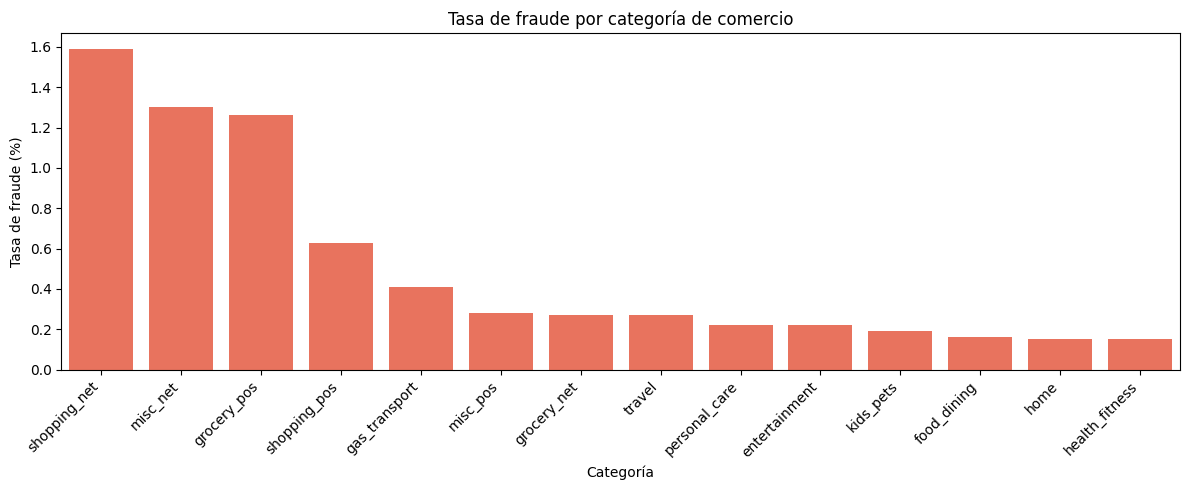

In [5]:
# 3. ¿Hay categorías de comercio con mayor incidencia de fraude?
plot_fraud_by_category(df)

La tasa de fraude varía significativamente entre categorías. `shopping_net` (compras minoristas en línea, 1.59%) tiene una tasa diez veces mayor que `home` y `health_fitness` (0.15%). Esa diferencia relativa entre categorías es lo que le da valor a esta variable para el modelo: no es que el fraude sea frecuente en términos absolutos, sino que la probabilidad de fraude cambia considerablemente dependiendo del tipo de comercio.

Dos de las tres categorías con mayor tasa son transacciones en línea (`shopping_net` y `misc_net`), lo que es coherente con que los canales digitales no requieren la presencia física de la tarjeta. La categoría (`category`) es una variable relevante para incluir en el modelo.

Tasa de fraude por hora:
hora
0     1.36
1     1.35
2     1.30
3     1.32
4     0.10
5     0.13
6     0.09
7     0.12
8     0.10
9     0.10
10    0.09
11    0.10
12    0.09
13    0.10
14    0.11
15    0.11
16    0.10
17    0.10
18    0.12
19    0.11
20    0.11
21    0.11
22    2.60
23    2.55

Tasa de fraude por día:
dia
Monday       0.40
Tuesday      0.47
Wednesday    0.61
Thursday     0.64
Friday       0.64
Saturday     0.57
Sunday       0.46


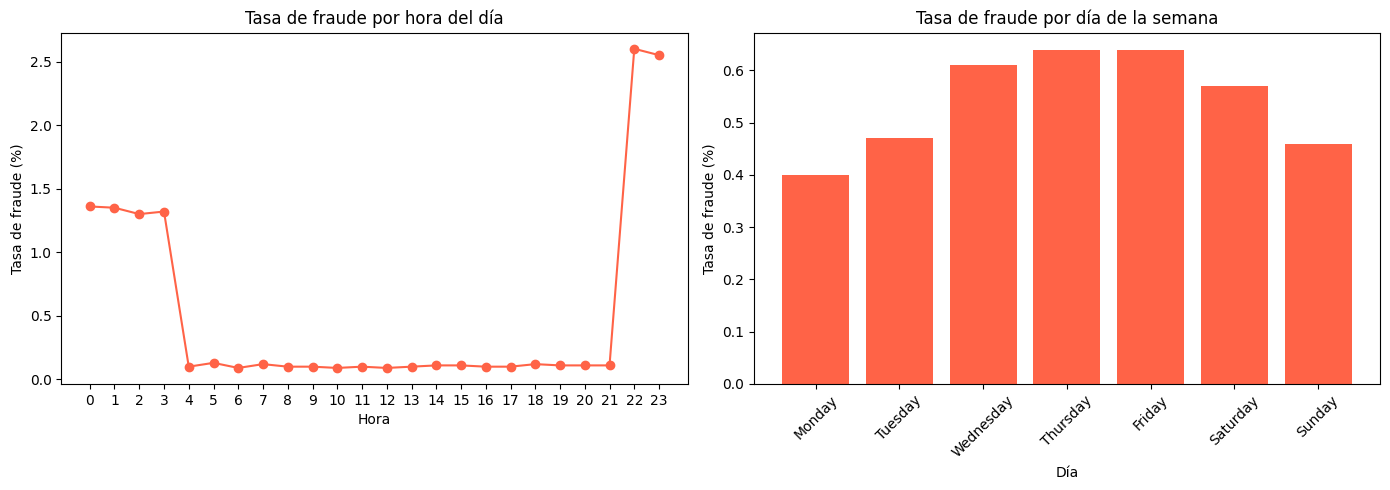

In [6]:
# 4. ¿El fraude sigue patrones temporales?
plot_time_patterns(df)

Las horas nocturnas (22:00, 23:00 y 0:00-3:00) concentran tasas entre 20 y 25 veces superiores al horario diurno. Esto sugiere que el fraude se ejecuta principalmente cuando los titulares están dormidos y es menos probable que reciban y reaccionen a alertas en tiempo real. La hora de la transacción es una variable con alto poder discriminativo y debe derivarse del campo `trans_date_trans_time` durante el preprocesamiento.

Por día de la semana la variación es menor y el patrón menos pronunciado, aunque sigue siendo una variable válida para incluir en el modelo.

Tasa de fraude por género:
   Género   Total  Fraudes  Tasa (%)
 Femenino 1014749     4899      0.48
Masculino  837645     4752      0.57


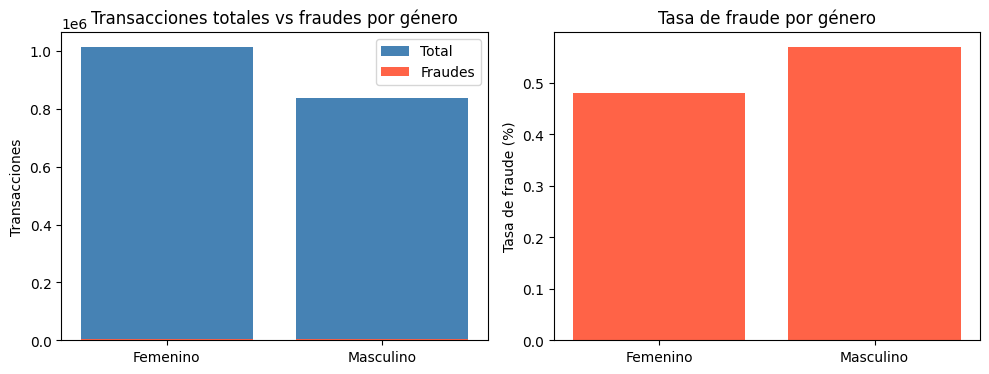

In [7]:
# 5. ¿Existe diferencia en la tasa de fraude entre géneros?
plot_fraud_by_gender(df)

La diferencia en la tasa de fraude entre géneros es mínima: 0.48% en transacciones de titulares femeninos y 0.57% en masculinos. A diferencia de la hora del día (diferencia de 20-25 veces) o la categoría del comercio (diferencia de 10 veces), el género aporta muy poco poder discriminativo al modelo.

Dado que la diferencia es marginal y que utilizar el género como variable predictiva introduce riesgos de sesgo de género, esta variable se descarta como entrada al modelo. Este punto se retoma en el análisis crítico.

## 4. Preprocesamiento

## 5. Modelo 1 — Isolation Forest

## 6. Modelo 2 — Autoencoder (Red Neuronal)

## 7. Evaluación Comparativa

## 8. Sistema Interactivo

## 9. Análisis Crítico

## 10. Conclusiones